## Gloves are Off!!


Example Corpus:

"I like deep learning."

"I like NLP."

"I enjoy flying."

{"I", "like", "deep", "learning", "NLP", "enjoy", "flying"}

Let us consider symmetric window of size 1 ($\pm 1$ word).

![GloVe Embedding](Glove.png)


This is the probability we'll see word $k$ in the context of word $i$.
The formula is: $P(k \mid i) = \frac{X_{ik}}{X_i}$ ($\frac{\text{Count of (i, k)}}{\text{Total context words for i}}$)

Let's do this for our "ice" vs. "steam" analogy.
* Let $i = \text{like}$
* Let $j = \text{enjoy}$

We will "probe" this relationship with three different $k$ words.

**Probe 1: $k = \text{I}$** (a word related to both)
* $P(\text{I} \mid \text{like}) = \frac{X_{\text{like, I}}}{X_{\text{like}}} = \frac{2}{4} = 0.5$
* $P(\text{I} \mid \text{enjoy}) = \frac{X_{\text{enjoy, I}}}{X_{\text{enjoy}}} = \frac{1}{2} = 0.5$

**Probe 2: $k = \text{NLP}$** (a word related to `like` but not `enjoy`)
* $P(\text{NLP} \mid \text{like}) = \frac{X_{\text{like, NLP}}}{X_{\text{like}}} = \frac{1}{4} = 0.25$
* $P(\text{NLP} \mid \text{enjoy}) = \frac{X_{\text{enjoy, NLP}}}{X_{\text{enjoy}}} = \frac{0}{2} = 0$

**Probe 3: $k = \text{flying}$** (a word related to `enjoy` but not `like`)
* $P(\text{flying} \mid \text{like}) = \frac{X_{\text{like, flying}}}{X_{\text{like}}} = \frac{0}{4} = 0$
* $P(\text{flying} \mid \text{enjoy}) = \frac{X_{\text{enjoy, flying}}}{X_{\text{enjoy}}} = \frac{1}{2} = 0.5$

---

### 5. Step 3: Calculate the Ratios

Now we can build the final table you asked about. The goal of GloVe is to learn vectors $w$ such that their dot products can model these ratios.

| Probe word ($k$) | $P(k \mid \text{like})$ | $P(k \mid \text{enjoy})$ | Ratio: $P(k \mid \text{like}) / P(k \mid \text{enjoy})$ |
| :--- | :--- | :--- | :--- |
| $k = \text{I}$ | 0.5 | 0.5 | **1.0** |
| $k = \text{NLP}$ | 0.25 | 0 | **$\infty$ (Very Large)** |
| $k = \text{flying}$ | 0 | 0.5 | **0 (Very Small)** |


* **"I"** is equally associated with "like" and "enjoy", so the ratio is 1.
* **"NLP"** is exclusively associated with "like", so the ratio is huge.
* **"flying"** is exclusively associated with "enjoy", so the ratio is tiny (zero).

The GloVe model is trained to learn vectors $w_{\text{like}}$, $w_{\text{enjoy}}$, $w_{\text{NLP}}$, etc., so that $(w_{\text{like}} - w_{\text{enjoy}}) \cdot w_k$ approximates $\log(\text{Ratio})$.

Lets take another example

Probe $k = \text{"fire"}$

$P(\text{fire} \mid \text{hot}) / P(\text{fire} \mid \text{cold}) = \text{Large} / \text{Small} = \text{Very Large Number}$.

$\log(\text{Very Large Number}) = \text{A Large **Positive** Number}$.

$$(w_{\text{hot}} - w_{\text{cold}}) \cdot w_{\text{fire}} \approx \text{Large Positive Number}$$

The model is forced to make the vector for "fire" point in the same direction as the "temperature-difference" arrow. It learns that "fire" is on the "hot" side of the map.

In [31]:
from gensim.downloader import load
glove_vectors = load("glove-wiki-gigaword-50") 
print(f"Similarity (GloVe): {glove_vectors.similarity('man', 'king')}")
print(f"Analogy (GloVe): {glove_vectors.most_similar(positive=['queen','man'], negative=['woman'])[0]}")

Similarity (GloVe): 0.5309377312660217
Analogy (GloVe): ('king', 0.8612024784088135)


---

### Word2Vec (CBOW/Skip-Gram)

* **Intuition:** Know a word by the company it keeps. We learn word vectors by training a simple neural network to do a prediction task based on a word's local neighbors. The vectors are the *byproduct* of this task.
    * **CBOW (Continuous Bag-of-Words):** Predicts a *center* word from its neighbors (e.g., `[I, ___, NLP]` → "love").
    * **Skip-gram:** Predicts *neighbor* words from a *center* word (e.g., `love` → `[I, NLP]`).

* **Mini-Diagram (Skip-gram):**
    > **Corpus:** `... a brown dog barks at ...`
    > **Window:** `[ brown, dog, barks ]`    >
    > **Task:**
    > `Input: "dog"` → `Predict: "brown"`
    > `Input: "dog"` → `Predict: "barks"`
    >
    > (The model adjusts vectors $w_{\text{dog}}$, $\tilde{w}_{\text{brown}}$, and $\tilde{w}_{\text{barks}}$ to make this prediction better)

 **Result (After Training):** Because `dog` and `cat` share many positive context words (like `pet`, `food`, `chase`), their final vectors are close: `cos(dog, cat)` = 0.85.


In [33]:
from gensim.models import Word2Vec
sents = [["i", "love", "nlp"], ["nlp", "helps", "search"], ["i", "study", "ai"]]
  
w2v = Word2Vec(sents, vector_size=100, window=2, sg=1, negative=5, min_count=1)
   
print(w2v.wv["nlp"].shape) 
    
print(w2v.wv.similarity("nlp", "ai"))
    
print(w2v.wv.most_similar(positive=['nlp', 'love'], negative=['ai']))
    

(100,)
-0.052346736
[('study', -0.0335431843996048), ('i', -0.06004202738404274), ('helps', -0.06214021146297455), ('search', -0.09673995524644852)]



* **Limitation:** **No context.** The vector for 'river **bank**' and 'investment **bank**' is identical.

Also, needs a lot data.



### SimCSE (Contrastive Sentence Embeddings)

The goal is to make similar sentences have similar vectors.

Unsupervised
Pass the *same sentence* through a BERT-style model twice. Due to *dropout* (randomly turning off neurons), you get two slightly different vectors. The model is trained to pull these two "views" together and push all *other* sentences in the batch away.

Supervised
"Entailment" pairs (e.g., "A man is running" / "A person is jogging") are pulled together. "Contradiction" pairs are pushed apart.

    > `[ "I love NLP" ]` --(model + dropout A)--> `h1` \
                                                `->` Pull `h1`, `h2` together
    > `[ "I love NLP" ]` --(model + dropout B)--> `h2` / 
    >
    > `[ "Other sentences..." ]` ----------------> `negs` `->` Push `h1` away from `negs`

In [20]:
from sentence_transformers import SentenceTransformer, util
    
model = SentenceTransformer("princeton-nlp/sup-simcse-bert-base-uncased")
    
s1 = "A man is playing a guitar."
s2 = "A person is performing music."
s3 = "A cat is sleeping on the couch."
    
emb1 = model.encode(s1)
emb2 = model.encode(s2)
emb3 = model.encode(s3)
    
print("Sim(s1, s2):", util.cos_sim(emb1, emb2).item())
print("Sim(s1, s3):", util.cos_sim(emb1, emb3).item())

No sentence-transformers model found with name princeton-nlp/sup-simcse-bert-base-uncased. Creating a new one with mean pooling.


Sim(s1, s2): 0.7721748352050781
Sim(s1, s3): 0.3073956370353699


Exception ignored in: <function tqdm.__del__ at 0x7b5ab478ed40>
Traceback (most recent call last):
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


COMPARISON FOR VARIOUS TASKS

Classification (Positive and Negative Sentiment)

In [21]:
corpus = [
    "I love the new PyTorch update, it's so fast.",       
    "This pasta dish is terrible, truly awful.",         
    "Learning NLP with Python is a great experience.",   
    "The new Contriever model is amazing for retrieval.", 
    "My steak was cold and the service was slow.",        
    "I hate how complex BERT is to fine-tune."            
]

In [22]:
classification_labels = [1, 0, 1, 1, 0, 0]

In [23]:
retrieval_docs = corpus
retrieval_query = "Find me information on Python programming for NLP."

Semantic Textual Similarity (STS): This task checks if a model "understands" paraphrases. We need sentence pairs and a human-rated "similarity score"

In [24]:
sts_pairs = [
    ("A man is playing a guitar.", "A person is performing music."),
    ("The cat is sleeping on the couch.", "A dog is running in the park."),
    ("How do I install Python?", "What's the process for setting up Python?")
]

In [25]:
sts_human_scores = [0.8, 0.1, 0.9]

Tokenization & Vocabulary

In [26]:
text = "Learning NLP with Python is great."
tokens = text.lower().split()
print(f"Tokens: {tokens}")

vocab = sorted(list(set(tokens)))
print(f"Vocab: {vocab}")

Tokens: ['learning', 'nlp', 'with', 'python', 'is', 'great.']
Vocab: ['great.', 'is', 'learning', 'nlp', 'python', 'with']


BoW

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus)
print(f"BoW Shape: {X_bow.shape}")
print(f"First sentence vector (sparse):\n {X_bow[0]}")

BoW Shape: (6, 40)
First sentence vector (sparse):
 <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (1, 40)>
  Coords	Values
  (0, 18)	1
  (0, 32)	1
  (0, 21)	1
  (0, 25)	1
  (0, 37)	1
  (0, 16)	1
  (0, 29)	1
  (0, 9)	1


Word2Vec (SkipGram/CBOW)

In [28]:
from gensim.models import Word2Vec
import numpy as np

tokenized_corpus = [doc.lower().split() for doc in corpus]
w2v_cbow_model = Word2Vec(tokenized_corpus, vector_size=100, window=5, sg=0, min_count=1)
w2v_sg_model = Word2Vec(tokenized_corpus, vector_size=100, window=5, sg=1, min_count=1)
def mean_pool(model, sentence_tokens):
    vectors = [model.wv[word] for word in sentence_tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)
X_cbow = np.array([mean_pool(w2v_cbow_model, doc) for doc in tokenized_corpus])
X_sg = np.array([mean_pool(w2v_sg_model, doc) for doc in tokenized_corpus])

print(f"Word2Vec (CBOW) Shape: {X_cbow.shape}") 

Word2Vec (CBOW) Shape: (6, 100)


GloVe (Pre-trained)

In [34]:
from gensim.models import Word2Vec
tokenized_corpus = [doc.lower().split() for doc in corpus]
w2v_cbow_model = Word2Vec(tokenized_corpus, vector_size=100, window=5, sg=0, min_count=1)

from gensim.downloader import load
glove_model = load("glove-wiki-gigaword-100")

def mean_pool(keyed_vectors, sentence_tokens):
    vectors = [keyed_vectors[word] for word in sentence_tokens if word in keyed_vectors]
    if not vectors:
        return np.zeros(keyed_vectors.vector_size)
    return np.mean(vectors, axis=0)

X_cbow = np.array([mean_pool(w2v_cbow_model.wv, doc) for doc in tokenized_corpus])
X_glove = np.array([mean_pool(glove_model, doc) for doc in tokenized_corpus])
print(f"Word2Vec (CBOW) Shape: {X_cbow.shape}")
print(f"GloVe (Mean-Pooled) Shape: {X_glove.shape}")

Word2Vec (CBOW) Shape: (6, 100)
GloVe (Mean-Pooled) Shape: (6, 100)


Sentence Embeddings (SimCSE & Contriever)

In [35]:
from sentence_transformers import SentenceTransformer
simcse_model = SentenceTransformer("princeton-nlp/sup-simcse-bert-base-uncased")

contriever_model = SentenceTransformer("facebook/contriever")

X_simcse = simcse_model.encode(corpus, show_progress_bar=False)
X_contriever = contriever_model.encode(corpus, show_progress_bar=False)

print(f"SimCSE Shape: {X_simcse.shape}")
print(f"Contriever Shape: {X_contriever.shape}")

No sentence-transformers model found with name princeton-nlp/sup-simcse-bert-base-uncased. Creating a new one with mean pooling.
No sentence-transformers model found with name facebook/contriever. Creating a new one with mean pooling.
Exception ignored in: <function tqdm.__del__ at 0x7b5ab478ed40>
Traceback (most recent call last):
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


SimCSE Shape: (6, 768)
Contriever Shape: (6, 768)


Exception ignored in: <function tqdm.__del__ at 0x7b5ab478ed40>
Traceback (most recent call last):
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/mayank/miniconda3/lib/python3.12/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = np.array(classification_labels)

model_bow = LogisticRegression().fit(X_bow, y)
acc_bow = accuracy_score(y, model_bow.predict(X_bow))
print(f"Accuracy (BoW): {acc_bow:.2f}")

model_cbow = LogisticRegression().fit(X_cbow, y)
acc_cbow = accuracy_score(y, model_cbow.predict(X_cbow))
print(f"Accuracy (W2V-CBOW): {acc_cbow:.2f}")

model_glove = LogisticRegression().fit(X_glove, y)
acc_glove = accuracy_score(y, model_glove.predict(X_glove))
print(f"Accuracy (GloVe): {acc_glove:.2f}")

model_simcse = LogisticRegression().fit(X_simcse, y)
acc_simcse = accuracy_score(y, model_simcse.predict(X_simcse))
print(f"Accuracy (SimCSE): {acc_simcse:.2f}")

model_contriever = LogisticRegression().fit(X_contriever, y)
acc_contriever = accuracy_score(y, model_contriever.predict(X_contriever))
print(f"Accuracy (Contriever): {acc_contriever:.2f}")

Accuracy (BoW): 1.00
Accuracy (W2V-CBOW): 1.00
Accuracy (GloVe): 1.00
Accuracy (SimCSE): 1.00
Accuracy (Contriever): 1.00


In [37]:
from scipy.stats import spearmanr
from sentence_transformers import util

def get_sts_scores(model, pairs):
    s1 = [pair[0] for pair in pairs]
    s2 = [pair[1] for pair in pairs]
    if isinstance(model, SentenceTransformer):
        emb1 = model.encode(s1)
        emb2 = model.encode(s2)
        sims = util.cos_sim(emb1, emb2).diag().tolist() 
    else:
        sims = []
        for i in range(len(s1)):
            t1 = s1[i].lower().split()
            t2 = s2[i].lower().split()
            emb1 = mean_pool(model, t1).reshape(1, -1)
            emb2 = mean_pool(model, t2).reshape(1, -1)
            sims.append(util.cos_sim(emb1, emb2).item())
    return sims

glove_sims = get_sts_scores(glove_model, sts_pairs)
corr_glove, _ = spearmanr(sts_human_scores, glove_sims)
print(f"STS Correlation (GloVe): {corr_glove:.2f}")

simcse_sims = get_sts_scores(simcse_model, sts_pairs)
corr_simcse, _ = spearmanr(sts_human_scores, simcse_sims)
print(f"STS Correlation (SimCSE): {corr_simcse:.2f}")

STS Correlation (GloVe): -1.00
STS Correlation (SimCSE): 1.00


In [38]:
query = "Find me information on Python programming for NLP."
correct_doc_index = 2

q_glove = mean_pool(glove_model, query.lower().split()).reshape(1, -1)
doc_glove = X_glove 
scores_glove = util.cos_sim(q_glove, doc_glove)[0]
top_doc_glove = np.argmax(scores_glove)
print(f"Retrieval (GloVe): Found doc {top_doc_glove}. Correct? {top_doc_glove == correct_doc_index}")

q_simcse = simcse_model.encode(query)
scores_simcse = util.cos_sim(q_simcse, X_simcse)[0]
top_doc_simcse = np.argmax(scores_simcse)
print(f"Retrieval (SimCSE): Found doc {top_doc_simcse}. Correct? {top_doc_simcse == correct_doc_index}")

q_contriever = contriever_model.encode(query)
scores_contriever = util.dot_score(q_contriever, X_contriever)[0] 
top_doc_contriever = np.argmax(scores_contriever)
print(f"Retrieval (Contriever): Found doc {top_doc_contriever}. Correct? {top_doc_contriever == correct_doc_index}")

Retrieval (GloVe): Found doc 0. Correct? False
Retrieval (SimCSE): Found doc 2. Correct? True
Retrieval (Contriever): Found doc 2. Correct? True


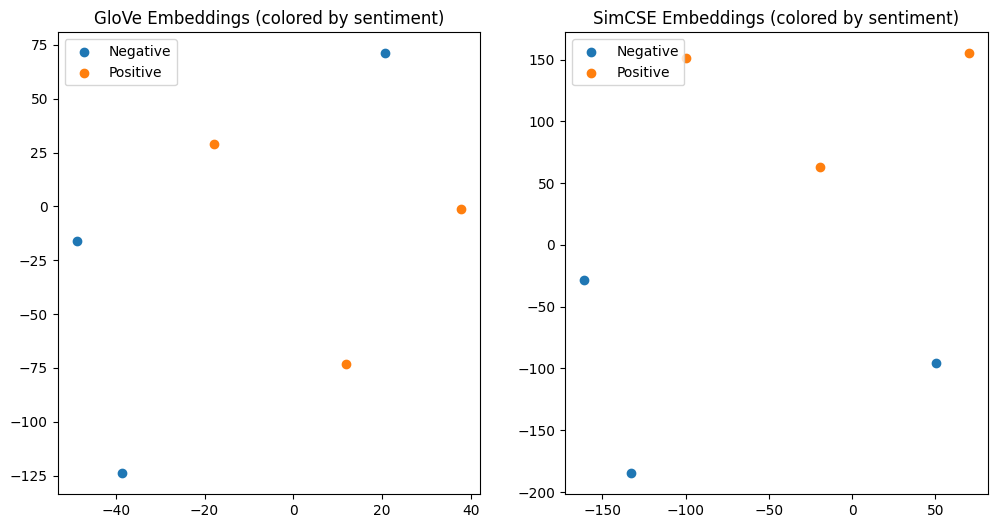

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

vectors_to_plot = {
    "GloVe": X_glove,
    "SimCSE": X_simcse
}
labels = np.array(classification_labels)

plt.figure(figsize=(12, 6))

for i, (name, vecs) in enumerate(vectors_to_plot.items()):
    tsne = TSNE(n_components=2, perplexity=3, random_state=42, init='random')
    vecs_2d = tsne.fit_transform(vecs)
    
    plt.subplot(1, 2, i + 1)
    plt.title(f"{name} Embeddings (colored by sentiment)")
    for label in [0, 1]:
        idx = (labels == label)
        plt.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], 
                    label=f"{'Negative' if label==0 else 'Positive'}")
    plt.legend()
plt.show()